In [ ]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)   

In [4]:
PROJECT_ROOT = Path.cwd().parent
# This line finds the current working directory (Path.cwd()) where your script is running, grabs its parent folder (.parent), and saves that path as PROJECT_ROOT. It essentially navigates one level up the folder tree to establish a baseline directory for your project.
# PROJECT_ROOT = path to bluestocks-mf-analytics/

RAW = PROJECT_ROOT / "data" / "raw"
REPORTS = PROJECT_ROOT / "reports"

REPORTS.mkdir(exist_ok=True)
# This actually creates the physical reports folder on your computer if it doesn't already exist. The exist_ok=True parameter is crucial because it prevents Python from crashing with an error if the folder was already created during a previous run.

In [5]:
# Load Data
fund_master = pd.read_csv(RAW / "01_fund_master.csv")
nav = pd.read_csv(RAW / "02_nav_history.csv")
benchmark = pd.read_csv(RAW / "10_benchmark_indices.csv")

In [ ]:
# parse dates
# originally dates are in str format, here we convert them to datetime format for easier manipulation and analysis
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])   

In [12]:
# prepare nav data

nav = nav.sort_values(
    ["amfi_code", "date"]
)
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [10]:
# Part 1: DAILY RETURNS
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

* **`nav.groupby("amfi_code")["nav"]`**: This groups your data by the `amfi_code` (a unique identifier for each mutual fund scheme) and isolates the `nav` column. This ensures that calculations for one mutual fund don't accidentally blend into a completely different fund.
* **`.pct_change()`**: Inside each fund's isolated group, this calculates the percentage change from one row to the next row—which represents the daily return, assuming your data is sorted chronally by date. The very first date for each fund will result in a `NaN` (blank) value because it has no previous day to compare against.
* **`nav["daily_return"] = ...`**: Finally, this takes those calculated percentages and assigns them to a brand-new column named `daily_return` in your original DataFrame.

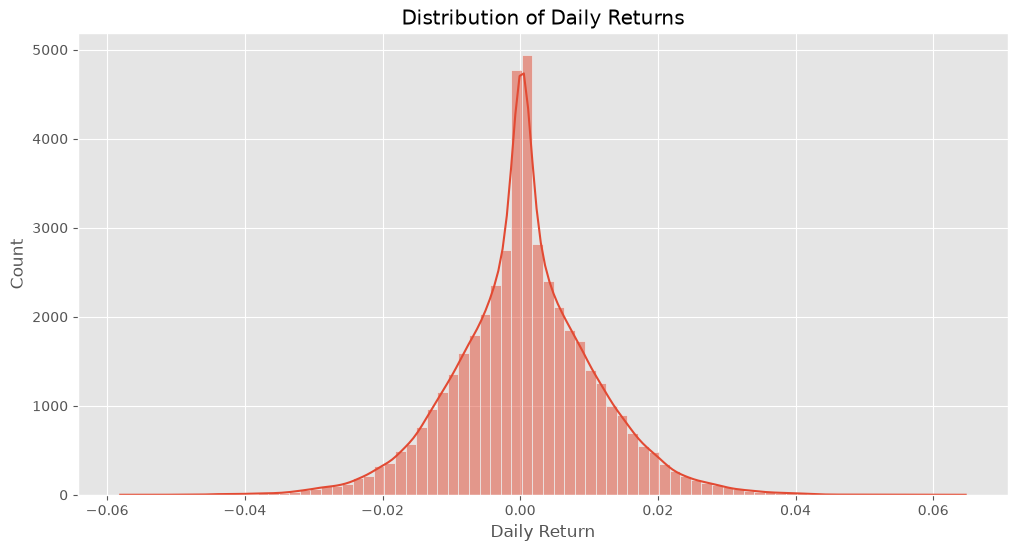

In [13]:
# daily return distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

* **`nav["daily_return"].dropna()`**: This passes the daily returns to Seaborn, but uses `.dropna()` to strip out any blank (`NaN`) values—like the ones from the very first day of data. Seaborn needs clean numbers to calculate the math for the chart without throwing a warning.
* **`bins=80`**: This slices your range of returns into 80 individual vertical bars (bins). A higher number like 80 gives you a highly detailed, granular look at the data, making it easy to spot narrow spikes or outliers (like an unusual single-day gain or drop).
* **`kde=True`**: This adds a **Kernel Density Estimate** line, which is a smooth curve drawn over the bars. It helps you instantly see the overall shape of the distribution—showing you whether your returns follow a normal bell curve, where the average return sits, and how wide the variance is.

In [14]:
# export
nav.to_csv(
    REPORTS/"daily_returns.csv",
    index=False
)

* **`nav.to_csv(..., index=False)`**: This converts the Pandas DataFrame into a standard CSV format and writes it to disk. The `index=False` argument tells Pandas *not* to save the row numbers (0, 1, 2...) as a separate column in your file, keeping the final spreadsheet clean and uncluttered.

### Compound Annual Growth Rate (CAGR) Formula

The formula for calculating CAGR is:

$$\text{CAGR} = \left( \frac{\text{Ending Value}}{\text{Beginning Value}} \right)^{\frac{1}{n}} - 1$$

Where:
* **Ending Value (EV):** The value of the investment at the end of the period.
* **Beginning Value (BV):** The value of the investment at the start of the period.
* **$n$:** The number of years (or periods) over which the investment grew.

---

### Alternative Inline Format
If your Markdown renderer doesn't support block equations, you can write it like this:

**CAGR = (Ending Value / Beginning Value)^(1 / n) - 1**

In [15]:
# create NAV matrix
nav_matrix = (
    nav.pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
)

nav_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


* **`nav.pivot(...)`**: This rearranges the DataFrame. It takes your vertical rows and spreads them across a 2D grid based on the three rules you provide inside the parentheses:
* **`index="date"`**: Sets the rows of your new matrix to be the distinct dates. Every unique date gets exactly one row.
* **`columns="amfi_code"`**: Turns each unique mutual fund scheme code into its own separate column.
* **`values="nav"`**: Fills the intersection cells of those rows and columns with the actual asset values (`nav`) for that specific fund on that specific date.


* **`nav_matrix.head()`**: Displays the first 5 rows of this newly generated matrix. It lets you visually verify the transformation—you will see a clean timeline running down the left side, with each column representing a different mutual fund's price movement over time.

In [ ]:
# CAGR Function

def calculate_cagr(nav_series , years):
    nav_series = nav_series.dropna()
    trading_days = years * 252

    if(len(nav_series) < trading_days):
        return np.nan
    
    start_nav = nav_series.iloc[-trading_days]
    end_nav = nav_series.iloc[-1]

    cagr = (end_nav / start_nav) ** (1 / years) - 1
    return cagr

In [17]:
# compute cagr

results = []
for scheme in nav_matrix.columns:
    series = nav_matrix[scheme]

    results.append(
        {
            "amfi_code": scheme,
            "CAGR_1Y":calculate_cagr(series,1),
            "CAGR_3Y":calculate_cagr(series,3),
            "CAGR_5Y":calculate_cagr(series,5),
        }
    )
cagr = pd.DataFrame(results)

In [18]:
# Add Scheme Names
cagr = cagr.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)
cagr = cagr[
    [
        "amfi_code",
        "scheme_name",
        "CAGR_1Y",
        "CAGR_3Y",
        "CAGR_5Y"
    ]
]
cagr.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.033055,-0.000316,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.025018,0.046143,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.477346,0.336292,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.450939,0.325286,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.242421,-0.026965,NaN
5,101208,ABSL Liquid Fund - Regular - Growth,0.068543,0.060762,NaN
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.183185,0.175201,NaN
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.132261,-0.018322,NaN
8,102887,UTI Flexi Cap Fund - Regular - Growth,0.127279,0.256630,NaN
9,118632,Nippon India Large Cap Fund - Regular - Growth,0.217768,0.180886,NaN


In [19]:
cagr.to_csv(
    REPORTS/"cagr_summary.csv",
    index=False
)

In [ ]:
# Rank Funds by 3-Year CAGR

# This sorts your cagr DataFrame by the 3-year CAGR column in descending order (highest growth first) and grabs the top 10 rows using .head(10).
top10 = (
    cagr.sort_values(
        "CAGR_3Y",
        ascending=False
    ).head(10)
)

# This builds the horizontal bar chart (orientation="h"). It plots the 3-year growth percentage on the X-axis against the mutual fund names on the Y-axis. It also assigns the raw CAGR numbers to the text attribute so they can be displayed directly on the bars.
fig = px.bar(
    top10,
    x = "CAGR_3Y",
    y = "scheme_name",
    orientation="h",
    title="Top 10 Funds by 3-Year CAGR",
    text = "CAGR_3Y"
)

# This formats the labels on the bars. texttemplate = "%{text:.2%}" converts decimal values (like 0.1543) into neatly formatted percentages with two decimal places (like 15.43%). textposition = "outside" places these labels cleanly right next to the tips of the bars rather than inside them.
fig.update_traces(
    texttemplate = "%{text:.2%}",
    textposition = "outside"
)

# This cleans up the chart's overall look. It applies a minimalist white background theme (plotly_white) and forces the Y-axis to display the funds in ascending order. Because the chart is horizontal, sorting the categories in "total ascending" order ensures the absolute highest-performing fund sits proudly at the very top of the chart.
fig.update_layout(
    template = "plotly_white",
    yaxis = dict(categoryorder = "total ascending")
)
fig.show()

Note: 5-year CAGR values are unavailable because the NAV history spans approximately four years (2022–2025). Therefore, 5-year CAGR has been left as NaN.